In [ ]:
import numpy as np
import pandas as pd
df=pd.read_csv("/content/insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [ ]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### EDA


In [ ]:
df['bmi'].skew()

np.float64(0.2840471105987448)

<Axes: xlabel='bmi', ylabel='Count'>

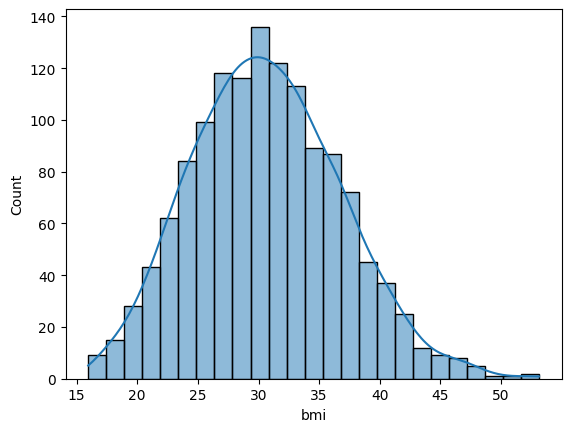

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot (df["bmi"],kde=True )

As there is skewness in the data, we will normalize it using boxcox

* boxcox to normalize "bmi"
* boxcox to normalize "charges"




<Axes: xlabel='bmi_boxcox', ylabel='Count'>

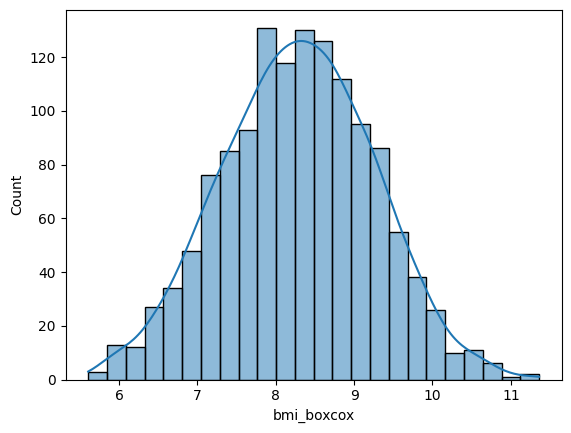

In [ ]:
from scipy.stats import boxcox

df["bmi_boxcox"], lam = boxcox(df["bmi"])
sns.histplot (df["bmi_boxcox"],kde=True )

In [ ]:
df['charges'].skew()

np.float64(1.5158796580240388)

<Axes: xlabel='charges', ylabel='Count'>

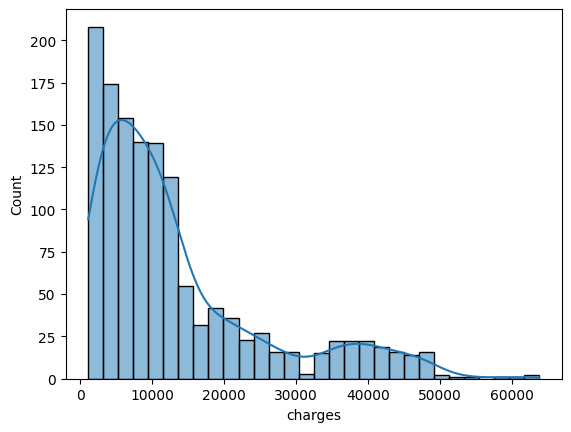

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot (df["charges"],kde=True )

Right skewed

<Axes: xlabel='charges_boxcox', ylabel='Count'>

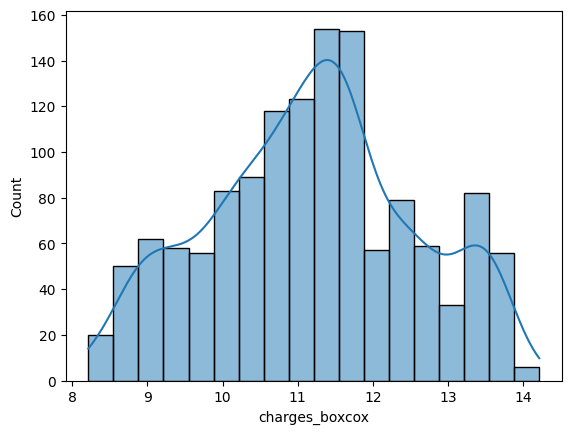

In [ ]:
from scipy.stats import boxcox
df["charges_boxcox"],_=boxcox(df["charges"]+1)
sns.histplot (df["charges_boxcox"],kde=True )

As there is skewness in the data, we will remove skewness and make the graph normal distribution using boxcox




In [ ]:
df['charges_boxcox'].skew()

np.float64(-0.008708920714070438)

In [ ]:
df['bmi_boxcox'].skew()

np.float64(-0.007092884185972351)

Skewness got removed

In [ ]:
(df["charges"] == 0).sum()


np.int64(0)

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_boxcox,charges_boxcox
0,19,female,27.900,0,yes,southwest,16884.92400,7.887106,12.121119
1,18,male,33.770,1,no,southeast,1725.55230,8.811784,8.805044
2,28,male,33.000,3,no,southeast,4449.46200,8.695722,10.142156
3,33,male,22.705,0,no,northwest,21984.47061,6.976455,12.526566
4,32,male,28.880,0,no,northwest,3866.85520,8.048320,9.940530


In [ ]:

df['bmi_cat'] = pd.cut(
    df['bmi'],
    bins=[0, 18.5, 25, 30, 100],
    labels=['under', 'normal', 'over', 'obese'])

df['age_group'] = pd.cut(
    df['age'],
    bins=[17, 30, 45, 60, 100],
    labels=['young', 'adult', 'mature', 'senior'])

df['age_smoker'] = df['age'] * (df['smoker'] == 'yes').astype(int)
df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_boxcox,charges_boxcox,bmi_cat,age_group,age_smoker
0,19,female,27.900,0,yes,southwest,16884.92400,7.887106,12.121119,over,young,19
1,18,male,33.770,1,no,southeast,1725.55230,8.811784,8.805044,obese,young,0
2,28,male,33.000,3,no,southeast,4449.46200,8.695722,10.142156,obese,young,0
3,33,male,22.705,0,no,northwest,21984.47061,6.976455,12.526566,normal,adult,0
4,32,male,28.880,0,no,northwest,3866.85520,8.048320,9.940530,over,adult,0


<Axes: xlabel='bmi_cat', ylabel='charges'>

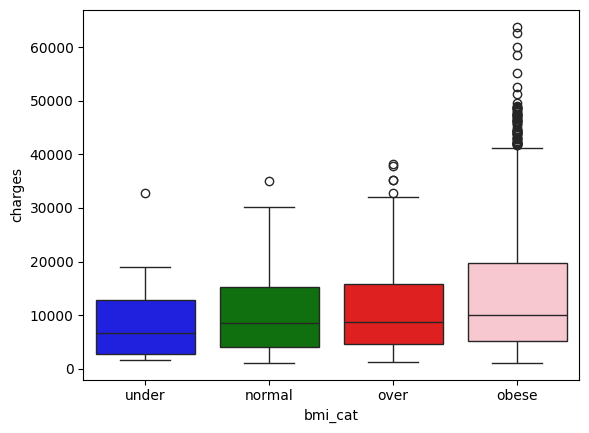

In [ ]:
sns.boxplot(x="bmi_cat",y="charges",data=df,
    hue='bmi_cat',
    palette=['blue', 'green', 'red', 'pink'],
    legend=False)

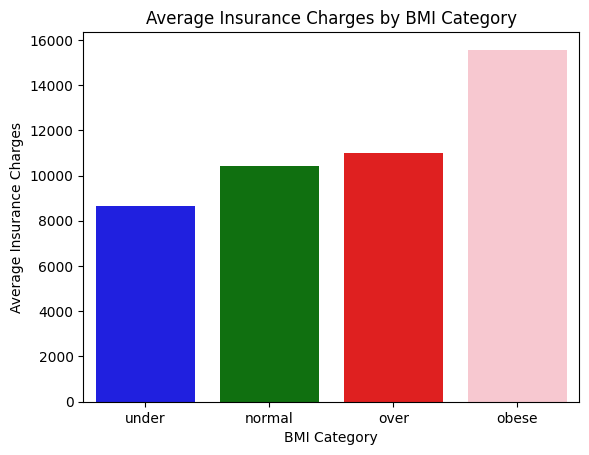

In [ ]:
sns.barplot(
    x='bmi_cat',
    y='charges',
    data=df,
    hue='bmi_cat',
    palette=['blue', 'green', 'red', 'pink'],
    legend=False,
    errorbar=None,estimator='mean'
)

plt.xlabel('BMI Category')
plt.ylabel('Average Insurance Charges')
plt.title('Average Insurance Charges by BMI Category')
plt.show()

<Axes: xlabel='smoker', ylabel='charges'>

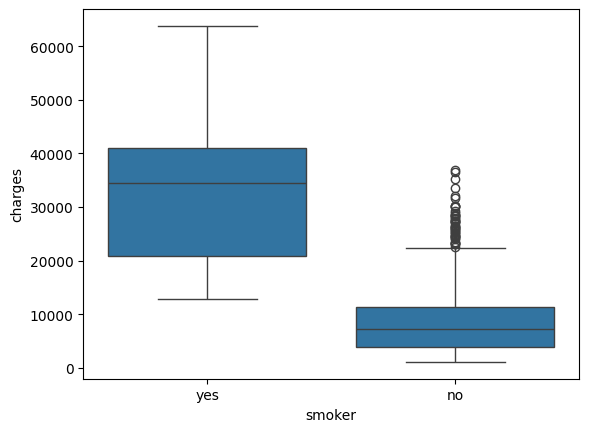

In [ ]:
sns.boxplot(x="smoker",y="charges",data=df)

<Axes: >

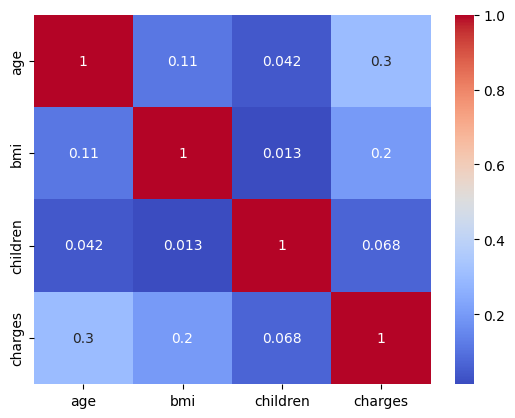

In [ ]:
nums_col=["age","bmi","children","charges"]
corr= df[nums_col].corr()
sns.heatmap(corr,annot=True,cmap="coolwarm")



In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_boxcox,charges_boxcox,bmi_cat,age_group,age_smoker
0,19,female,27.900,0,yes,southwest,16884.92400,7.887106,12.121119,over,young,19
1,18,male,33.770,1,no,southeast,1725.55230,8.811784,8.805044,obese,young,0
2,28,male,33.000,3,no,southeast,4449.46200,8.695722,10.142156,obese,young,0
3,33,male,22.705,0,no,northwest,21984.47061,6.976455,12.526566,normal,adult,0
4,32,male,28.880,0,no,northwest,3866.85520,8.048320,9.940530,over,adult,0


In [ ]:
# for categorical
for col in ["sex","smoker","region","bmi_cat","age_group"]:
  print(col,df[col].value_counts())

sex sex
male      676
female    662
Name: count, dtype: int64
smoker smoker
no     1064
yes     274
Name: count, dtype: int64
region region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64
bmi_cat bmi_cat
obese     705
over      386
normal    226
under      21
Name: count, dtype: int64
age_group age_group
young     444
mature    409
adult     394
senior     91
Name: count, dtype: int64


In [ ]:
print("Shape:", df.shape)

Shape: (1338, 12)


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             1338 non-null   int64   
 1   sex             1338 non-null   object  
 2   bmi             1338 non-null   float64 
 3   children        1338 non-null   int64   
 4   smoker          1338 non-null   object  
 5   region          1338 non-null   object  
 6   charges         1338 non-null   float64 
 7   bmi_boxcox      1338 non-null   float64 
 8   charges_boxcox  1338 non-null   float64 
 9   bmi_cat         1338 non-null   category
 10  age_group       1338 non-null   category
 11  age_smoker      1338 non-null   int64   
dtypes: category(2), float64(4), int64(3), object(3)
memory usage: 107.7+ KB


In [ ]:
df.describe()

,age,bmi,children,charges,bmi_boxcox,charges_boxcox,age_smoker
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265,8.282339,11.191088,7.887145
std,14.049960,6.098187,1.205493,12110.011237,0.965002,1.364867,16.772800
min,18.000000,15.960000,0.000000,1121.873900,5.605555,8.215470,0.000000
25%,27.000000,26.296250,0.000000,4740.287150,7.616548,10.233524,0.000000
50%,39.000000,30.400000,1.000000,9382.033000,8.292634,11.234945,0.000000
75%,51.000000,34.693750,2.000000,16639.912515,8.949153,12.098797,0.000000
max,64.000000,53.130000,5.000000,63770.428010,11.361024,14.210812,64.000000


In [ ]:
df.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0
bmi_boxcox,0
charges_boxcox,0
bmi_cat,0


so there are no null values here


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1


In [ ]:
df = df.drop_duplicates()

In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
print("Shape:", df.shape)

Shape: (1337, 12)


Duplicate row removed and shape got modified

In [ ]:
print(df["sex"].unique())
print(df["smoker"].unique())
print(df["region"].unique())

['female' 'male']
['yes' 'no']
['southwest' 'southeast' 'northwest' 'northeast']


In [ ]:
x = df.drop(["charges", "charges_boxcox"], axis=1)
y = df["charges_boxcox"]

In [ ]:
x.head()

,age,sex,bmi,children,smoker,region,bmi_boxcox,bmi_cat,age_group,age_smoker
0,19,female,27.900,0,yes,southwest,7.887106,over,young,19
1,18,male,33.770,1,no,southeast,8.811784,obese,young,0
2,28,male,33.000,3,no,southeast,8.695722,obese,young,0
3,33,male,22.705,0,no,northwest,6.976455,normal,adult,0
4,32,male,28.880,0,no,northwest,8.048320,over,adult,0


In [ ]:
x = pd.get_dummies(
    x,
    columns=["sex", "smoker", "region", "bmi_cat", "age_group"],
    drop_first=True,dtype= int
)
print(x.dtypes)

age                   int64
bmi                 float64
children              int64
bmi_boxcox          float64
age_smoker            int64
sex_male              int64
smoker_yes            int64
region_northwest      int64
region_southeast      int64
region_southwest      int64
bmi_cat_normal        int64
bmi_cat_over          int64
bmi_cat_obese         int64
age_group_adult       int64
age_group_mature      int64
age_group_senior      int64
dtype: object


In [ ]:
x

,age,bmi,children,bmi_boxcox,age_smoker,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,bmi_cat_normal,bmi_cat_over,bmi_cat_obese,age_group_adult,age_group_mature,age_group_senior
0,19,27.900,0,7.887106,19,0,1,0,0,1,0,1,0,0,0,0
1,18,33.770,1,8.811784,0,1,0,0,1,0,0,0,1,0,0,0
2,28,33.000,3,8.695722,0,1,0,0,1,0,0,0,1,0,0,0
3,33,22.705,0,6.976455,0,1,0,1,0,0,1,0,0,1,0,0
4,32,28.880,0,8.048320,0,1,0,1,0,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,8.382548,0,1,0,1,0,0,0,0,1,0,1,0
1334,18,31.920,0,8.530443,0,0,0,0,0,0,0,0,1,0,0,0
1335,18,36.850,0,9.262316,0,0,0,0,1,0,0,0,1,0,0,0
1336,21,25.800,0,7.531036,0,0,0,0,0,1,0,1,0,0,0,0


In [ ]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1337 non-null   int64  
 1   bmi               1337 non-null   float64
 2   children          1337 non-null   int64  
 3   bmi_boxcox        1337 non-null   float64
 4   age_smoker        1337 non-null   int64  
 5   sex_male          1337 non-null   int64  
 6   smoker_yes        1337 non-null   int64  
 7   region_northwest  1337 non-null   int64  
 8   region_southeast  1337 non-null   int64  
 9   region_southwest  1337 non-null   int64  
 10  bmi_cat_normal    1337 non-null   int64  
 11  bmi_cat_over      1337 non-null   int64  
 12  bmi_cat_obese     1337 non-null   int64  
 13  age_group_adult   1337 non-null   int64  
 14  age_group_mature  1337 non-null   int64  
 15  age_group_senior  1337 non-null   int64  
dtypes: float64(2), int64(14)
memory usage: 177.6 KB

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
print(x_train_scaled[:5])

[[-1.1576804  -0.99692768 -0.90790804 -1.00164632 -0.46280522  0.97140947
  -0.50029231 -0.57266946 -0.60581158 -0.57410974  2.17883268 -0.64926308
  -1.03136151 -0.64635275 -0.663853   -0.26672511]
 [-1.30061876 -0.79276204  0.7669042  -0.77501387 -0.46280522  0.97140947
  -0.50029231 -0.57266946 -0.60581158 -0.57410974 -0.45896136  1.5402077
  -1.03136151 -0.64635275 -0.663853   -0.26672511]
 [ 0.91492586  1.15466402  0.7669042   1.14332521 -0.46280522 -1.029432
  -0.50029231  1.74620801 -0.60581158 -0.57410974 -0.45896136 -0.64926308
   0.96959213 -0.64635275  1.50635758 -0.26672511]
 [ 1.70108686  1.80683684 -0.90790804  1.71069509 -0.46280522  0.97140947
  -0.50029231 -0.57266946  1.65067825 -0.57410974 -0.45896136 -0.64926308
   0.96959213 -0.64635275 -0.663853    3.74917831]
 [ 0.55757996 -0.6514166   0.7669042  -0.62153247 -0.46280522 -1.029432
  -0.50029231 -0.57266946 -0.60581158 -0.57410974 -0.45896136  1.5402077
  -1.03136151 -0.64635275  1.50635758 -0.26672511]]


In [ ]:
from sklearn.linear_model import LinearRegression

# Create Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(x_train_scaled, y_train)

# Make predictions
y_pred = linear_model.predict(x_test_scaled)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 0.3705136025250989
Mean Squared Error (MSE): 0.3013215109603868
Root Mean Squared Error (RMSE): 0.5489276008367467
R² Score: 0.8532598457696212


In [ ]:
numeric_cols = ['age', 'bmi', 'children', 'charges']

corr = df[numeric_cols].corr()

print(corr)

               age       bmi  children   charges
age       1.000000  0.109344  0.041536  0.298308
bmi       0.109344  1.000000  0.012755  0.198401
children  0.041536  0.012755  1.000000  0.067389
charges   0.298308  0.198401  0.067389  1.000000


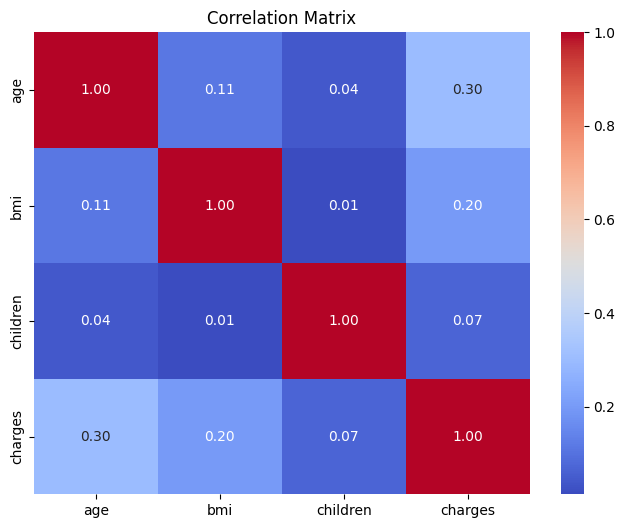

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import pandas as pd

X = df[['age', 'bmi', 'children']]

X = sm.add_constant(X)

vif = pd.DataFrame()
vif['Feature'] = X.columns
vif['VIF'] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif)

    Feature        VIF
0     const  31.949479
1       age   1.013754
2       bmi   1.012170
3  children   1.001797


In [ ]:
import statsmodels.formula.api as smf

model = smf.ols(
    'charges ~ age + bmi + children + C(smoker) + C(sex) + C(region)',
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.0
Date:                Sun, 30 Aug 2026   Prob (F-statistic):               0.00
Time:                        13:13:35   Log-Likelihood:                -13538.
No. Observations:                1337   AIC:                         2.709e+04
Df Residuals:                    1328   BIC:                         2.714e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept              -1.19

In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(
    model.resid,
    model.model.exog
)

labels = [
    'LM Statistic',
    'LM p-value',
    'F Statistic',
    'F p-value'
]

print(dict(zip(labels, bp_test)))

{'LM Statistic': np.float64(121.57123246349339), 'LM p-value': np.float64(1.5703556813489332e-22), 'F Statistic': np.float64(16.6038727467702), 'F p-value': np.float64(1.2509481711900126e-23)}


In [ ]:
model_robust = model.get_robustcov_results(cov_type='HC3')

print(model_robust.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     298.0
Date:                Sun, 30 Aug 2026   Prob (F-statistic):          5.13e-290
Time:                        13:13:35   Log-Likelihood:                -13538.
No. Observations:                1337   AIC:                         2.709e+04
Df Residuals:                    1328   BIC:                         2.714e+04
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept              -1.19

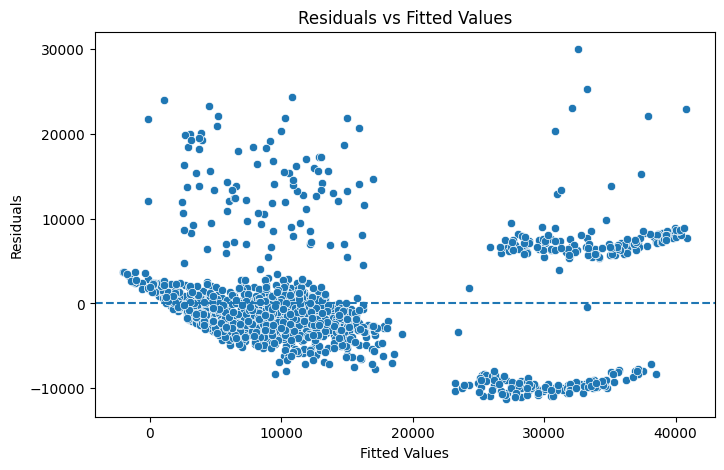

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

residuals = model.resid
fitted = model.fittedvalues

plt.figure(figsize=(8, 5))
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0, linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()

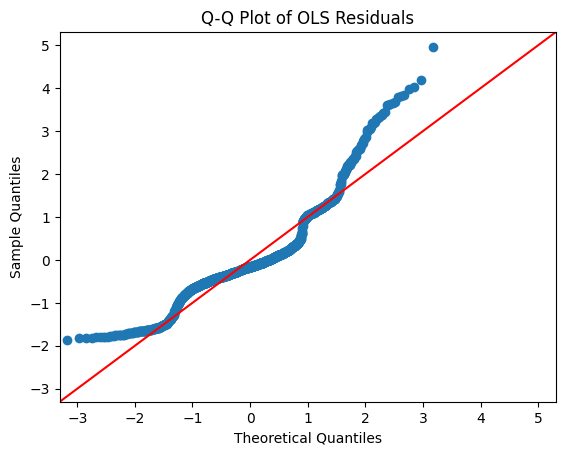

In [ ]:


sm.qqplot(model.resid, line='45', fit=True)

plt.title('Q-Q Plot of OLS Residuals')
plt.show()

In [ ]:
import statsmodels.formula.api as smf

model_boxcox = smf.ols(
    'charges_boxcox ~ age + bmi + children + C(smoker) + C(sex) + C(region)',
    data=df
).fit()

model_boxcox_robust = model_boxcox.get_robustcov_results(cov_type='HC3')

print(model_boxcox_robust.summary())

                            OLS Regression Results                            
Dep. Variable:         charges_boxcox   R-squared:                       0.771
Model:                            OLS   Adj. R-squared:                  0.769
Method:                 Least Squares   F-statistic:                     423.4
Date:                Sun, 30 Aug 2026   Prob (F-statistic):               0.00
Time:                        13:13:36   Log-Likelihood:                -1327.1
No. Observations:                1337   AIC:                             2672.
Df Residuals:                    1328   BIC:                             2719.
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  8

In [ ]:
df["charges_boxcox"].skew()

np.float64(-0.008403423739507742)

In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_boxcox = het_breuschpagan(
    model_boxcox.resid,
    model_boxcox.model.exog
)

labels = [
    'LM Statistic',
    'LM p-value',
    'F Statistic',
    'F p-value'
]

print(dict(zip(labels, bp_boxcox)))

{'LM Statistic': np.float64(69.7714255539873), 'LM p-value': np.float64(5.457204431480532e-12), 'F Statistic': np.float64(9.139674464036725), 'F p-value': np.float64(2.663095403303596e-12)}


In [ ]:
print("Residual skewness:", model_boxcox.resid.skew())
print("Target skewness:", df['charges_boxcox'].skew())

Residual skewness: 1.742268406147882
Target skewness: -0.008403423739507742


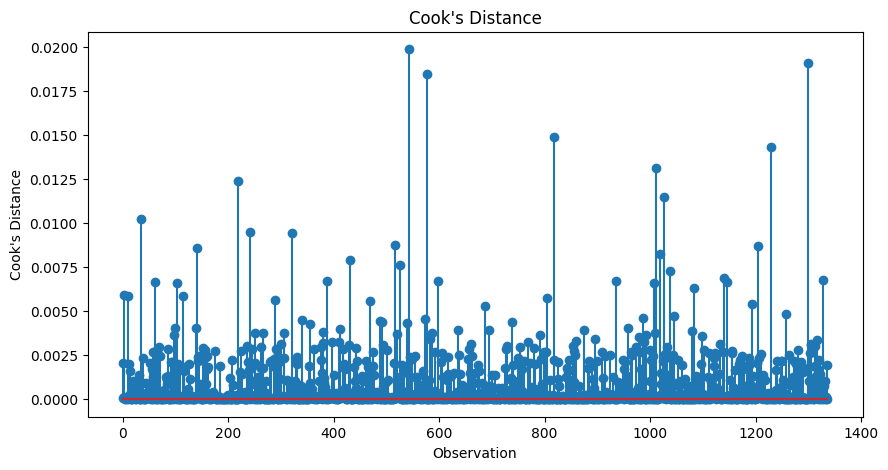

In [ ]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

influence = model.get_influence()
cooks_d = influence.cooks_distance[0]

plt.figure(figsize=(10, 5))
plt.stem(cooks_d)
plt.xlabel('Observation')
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance")
plt.show()

In [ ]:
threshold = 4 / len(df)

influential = df[cooks_d > threshold]

print("Threshold:", threshold)
print("Number of influential observations:", len(influential))

Threshold: 0.0029917726252804786
Number of influential observations: 85


In [ ]:
import numpy as np

cook_df = pd.DataFrame({
    'index': df.index,
    'cooks_distance': cooks_d
})

top_10 = cook_df.sort_values(
    'cooks_distance',
    ascending=False
).head(10)

print(top_10)

      index  cooks_distance
543     543        0.019849
1299   1300        0.019071
577     577        0.018437
818     819        0.014886
1229   1230        0.014305
1011   1012        0.013087
219     219        0.012393
1026   1027        0.011449
34       34        0.010229
242     242        0.009485


In [ ]:
top_indices = top_10['index'].astype(int)

print(df.loc[top_indices])

      age     sex     bmi  children smoker     region      charges  \
543    54  female  47.410         0    yes  southeast  63770.42801   
1300   45    male  30.360         0    yes  southeast  62592.87309   
577    31  female  38.095         1    yes  northeast  58571.07448   
819    33  female  35.530         0    yes  northwest  55135.40209   
1230   52    male  34.485         3    yes  northwest  60021.39897   
1012   61  female  33.330         4     no  southeast  36580.28216   
219    24  female  23.210         0     no  southeast  25081.76784   
1027   23    male  18.715         0     no  northwest  21595.38229   
34     28    male  36.400         1    yes  southwest  51194.55914   
242    55  female  26.800         1     no  southwest  35160.13457   

      bmi_boxcox  charges_boxcox bmi_cat age_group  age_smoker  
543    10.669352       14.210812   obese    mature          54  
1300    8.286290       14.180658   obese     adult          45  
577     9.438644       14.073417  

Potentially influential observations were identified using Cook's Distance. Although 85 observations exceeded the 4/n screening threshold, inspection of the most influential observations showed that they represented plausible insurance cases, particularly high-risk smokers with elevated BMI and/or age. Therefore, no observations were removed solely based on Cook's Distance.

In [ ]:
df_sensitivity = df.drop(index=top_indices)

model_sensitivity = smf.ols(
    'charges ~ age + bmi + children + C(smoker) + C(sex) + C(region)',
    data=df_sensitivity
).fit()

print(model_sensitivity.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.763
Model:                            OLS   Adj. R-squared:                  0.762
Method:                 Least Squares   F-statistic:                     530.7
Date:                Sun, 30 Aug 2026   Prob (F-statistic):               0.00
Time:                        13:13:36   Log-Likelihood:                -13360.
No. Observations:                1327   AIC:                         2.674e+04
Df Residuals:                    1318   BIC:                         2.678e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept              -1.17

In [ ]:
X = df[['age', 'bmi', 'children', 'smoker', 'sex', 'region']]
y = df['charges']

In [ ]:
from sklearn.model_selection import train_test_split

X = df[['age', 'bmi', 'children', 'smoker', 'sex', 'region']]
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Features and target
X = df[['age', 'bmi', 'children', 'smoker', 'sex', 'region']]
y = df['charges']

# Encode categorical variables BEFORE train-test split
X = pd.get_dummies(
    X,
    columns=['smoker', 'sex', 'region'],
    drop_first=True,
    dtype=int
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42)
# Linear Regression
model = LinearRegression()

# Train
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Evaluation
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Training R²:", train_r2)
print("Testing R²:", test_r2)
print("Training MAE:", train_mae)
print("Testing MAE:", test_mae)
print("Training RMSE:", train_rmse)
print("Testing RMSE:", test_rmse)

Training R²: 0.7299057809339075
Testing R²: 0.8069287081198011
Training MAE: 4181.901537775142
Testing MAE: 4177.045561036321
Training RMSE: 6081.106881541277
Testing RMSE: 5956.342894363588


In [ ]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


# --------------------------------------------
# 1. Select features and target
# --------------------------------------------

X = df[['age', 'bmi', 'children', 'smoker', 'sex', 'region']]
y = df['charges']


# --------------------------------------------
# 2. Convert categorical variables to numbers
# --------------------------------------------

X = pd.get_dummies(
    X,
    columns=['smoker', 'sex', 'region'],
    drop_first=True,
    dtype=int
)


# --------------------------------------------
# 3. Train-test split
# --------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# --------------------------------------------
# 4. Create Decision Tree Regressor
# --------------------------------------------

dt_model = DecisionTreeRegressor(
    random_state=42
)


# --------------------------------------------
# 5. Train the model
# --------------------------------------------

dt_model.fit(X_train, y_train)


# --------------------------------------------
# 6. Predictions
# --------------------------------------------

y_train_pred = dt_model.predict(X_train)
y_test_pred = dt_model.predict(X_test)


# --------------------------------------------
# 7. Evaluation
# --------------------------------------------

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))


# --------------------------------------------
# 8. Print results
# --------------------------------------------

print("DECISION TREE REGRESSION")
print("------------------------")

print("Training R² :", train_r2)
print("Testing R²  :", test_r2)

print("Training MAE:", train_mae)
print("Testing MAE :", test_mae)

print("Training RMSE:", train_rmse)
print("Testing RMSE :", test_rmse)

DECISION TREE REGRESSION
------------------------
Training R² : 1.0
Testing R²  : 0.8188820336469307
Training MAE: 0.0
Testing MAE : 2730.629848988806
Training RMSE: 0.0
Testing RMSE : 5769.014181311075


this clearly shows overfitting

In [ ]:
# Create a tuned Decision Tree
dt_tuned = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Train the model
dt_tuned.fit(X_train, y_train)

# Predictions
y_train_pred = dt_tuned.predict(X_train)
y_test_pred = dt_tuned.predict(X_test)

# Evaluation
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Results
print("TUNED DECISION TREE REGRESSION")
print("--------------------------------")

print("Training R² :", train_r2)
print("Testing R²  :", test_r2)

print("Training MAE :", train_mae)
print("Testing MAE  :", test_mae)

print("Training RMSE:", train_rmse)
print("Testing RMSE :", test_rmse)

TUNED DECISION TREE REGRESSION
--------------------------------
Training R² : 0.8657306460150244
Testing R²  : 0.895776025882278
Training MAE : 2392.492909641572
Testing MAE  : 2644.1597522221514
Training RMSE: 4287.591900830385
Testing RMSE : 4376.2755012217885


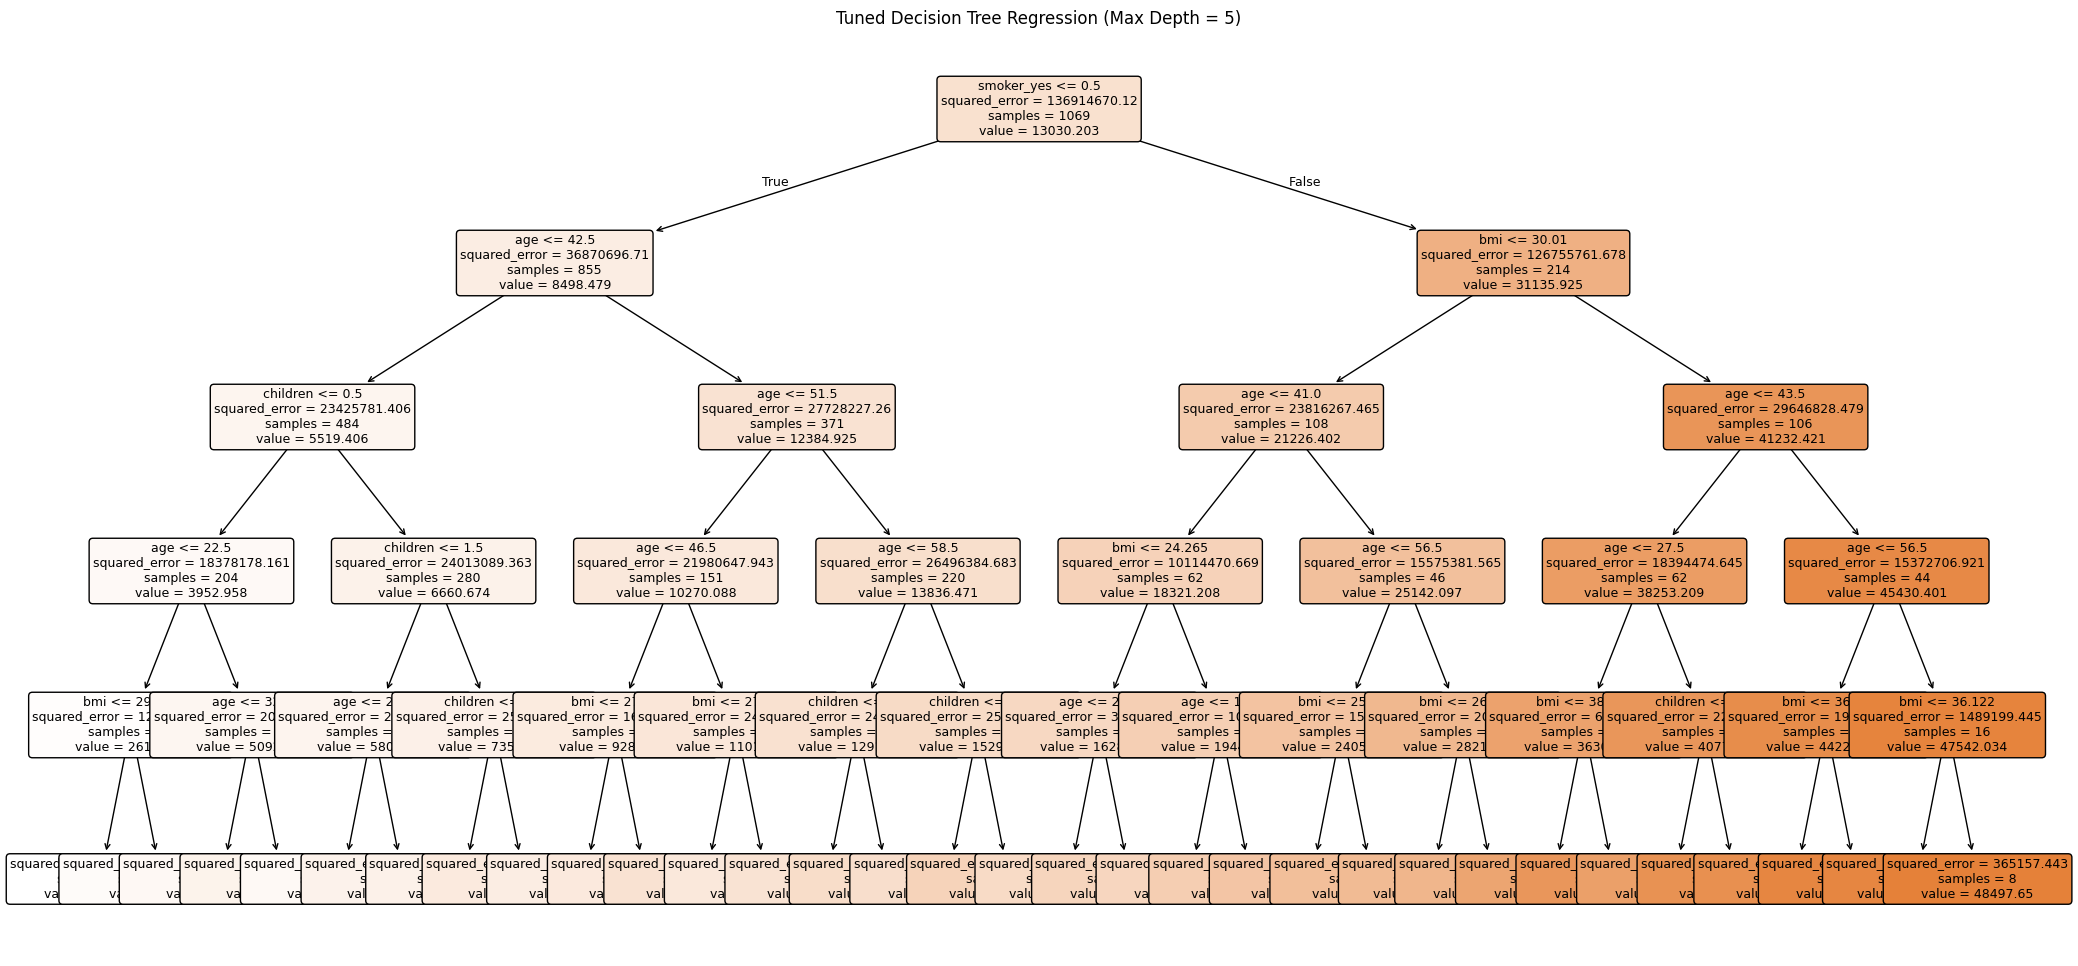

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(25, 12))

plot_tree(
    dt_tuned,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Tuned Decision Tree Regression (Max Depth = 5)")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

print("RANDOM FOREST REGRESSION")
print("------------------------")
print("Training R² :", r2_score(y_train, y_train_pred_rf))
print("Testing R²  :", r2_score(y_test, y_test_pred_rf))
print("Training MAE:", mean_absolute_error(y_train, y_train_pred_rf))
print("Testing MAE :", mean_absolute_error(y_test, y_test_pred_rf))
print("Training RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred_rf)))
print("Testing RMSE :", np.sqrt(mean_squared_error(y_test, y_test_pred_rf)))

RANDOM FOREST REGRESSION
------------------------
Training R² : 0.9751573399334161
Testing R²  : 0.8812255498742763
Training MAE: 1039.198870110598
Testing MAE : 2628.43573692674
Training RMSE: 1844.2680412340778
Testing RMSE : 4671.779689127993


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_train_pred_gb = gb_model.predict(X_train)
y_test_pred_gb = gb_model.predict(X_test)

print("GRADIENT BOOSTING REGRESSION")
print("----------------------------")
print("Training R² :", r2_score(y_train, y_train_pred_gb))
print("Testing R²  :", r2_score(y_test, y_test_pred_gb))
print("Training MAE:", mean_absolute_error(y_train, y_train_pred_gb))
print("Testing MAE :", mean_absolute_error(y_test, y_test_pred_gb))
print("Training RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred_gb)))
print("Testing RMSE :", np.sqrt(mean_squared_error(y_test, y_test_pred_gb)))

GRADIENT BOOSTING REGRESSION
----------------------------
Training R² : 0.9023428293682444
Testing R²  : 0.8999545600279003
Training MAE: 1997.6680426181754
Testing MAE : 2516.8219774196127
Training RMSE: 3656.596682967722
Testing RMSE : 4287.6516036792345


In [ ]:
from sklearn.model_selection import cross_val_score

models = {
    'Linear Regression': model,
    'Decision Tree': dt_tuned,
    'Random Forest': rf_model,
    'Gradient Boosting': gb_model
}

for name, m in models.items():

    scores = cross_val_score(
        m,
        X,
        y,
        cv=5,
        scoring='r2',
        n_jobs=-1
    )

    print("\n", name)
    print("Fold R² scores:", scores)
    print("Mean CV R²:", scores.mean())
    print("Std CV R²:", scores.std())


 Linear Regression
Fold R² scores: [0.76148609 0.70651382 0.77741544 0.73269494 0.7555821 ]
Mean CV R²: 0.7467384760760104
Std CV R²: 0.024706364468480433

 Decision Tree
Fold R² scores: [0.86919705 0.77783109 0.88838464 0.83859603 0.86480074]
Mean CV R²: 0.8477619089052919
Std CV R²: 0.038403973305869345

 Random Forest
Fold R² scores: [0.85505985 0.77819604 0.86978028 0.82988336 0.85236913]
Mean CV R²: 0.8370577359651314
Std CV R²: 0.03207943456372499

 Gradient Boosting
Fold R² scores: [0.86847705 0.79081428 0.8897371  0.84884991 0.85685625]
Mean CV R²: 0.8509469173786975
Std CV R²: 0.03306731300749359


In [ ]:
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],

    'Test R²': [
        r2_score(y_test, model.predict(X_test)),
        r2_score(y_test, dt_tuned.predict(X_test)),
        r2_score(y_test, rf_model.predict(X_test)),
        r2_score(y_test, gb_model.predict(X_test))
    ],

    'Test MAE': [
        mean_absolute_error(y_test, model.predict(X_test)),
        mean_absolute_error(y_test, dt_tuned.predict(X_test)),
        mean_absolute_error(y_test, rf_model.predict(X_test)),
        mean_absolute_error(y_test, gb_model.predict(X_test))
    ],

    'Test RMSE': [
        np.sqrt(mean_squared_error(y_test, model.predict(X_test))),
        np.sqrt(mean_squared_error(y_test, dt_tuned.predict(X_test))),
        np.sqrt(mean_squared_error(y_test, rf_model.predict(X_test))),
        np.sqrt(mean_squared_error(y_test, gb_model.predict(X_test)))
    ]
})

print(comparison)

               Model   Test R²     Test MAE    Test RMSE
0  Linear Regression  0.806929  4177.045561  5956.342894
1      Decision Tree  0.895776  2644.159752  4376.275501
2      Random Forest  0.881226  2628.435737  4671.779689
3  Gradient Boosting  0.899955  2516.821977  4287.651604


In [ ]:
dashboard_df = df[
    ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']
].copy()

dashboard_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
dashboard_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 115.9+ KB


In [ ]:
dashboard_df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
dashboard_df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
dashboard_df.to_csv('insurance_dashboard.csv', index=False)